Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       105
           1       0.84      0.64      0.72        74

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179

Saved tree image.


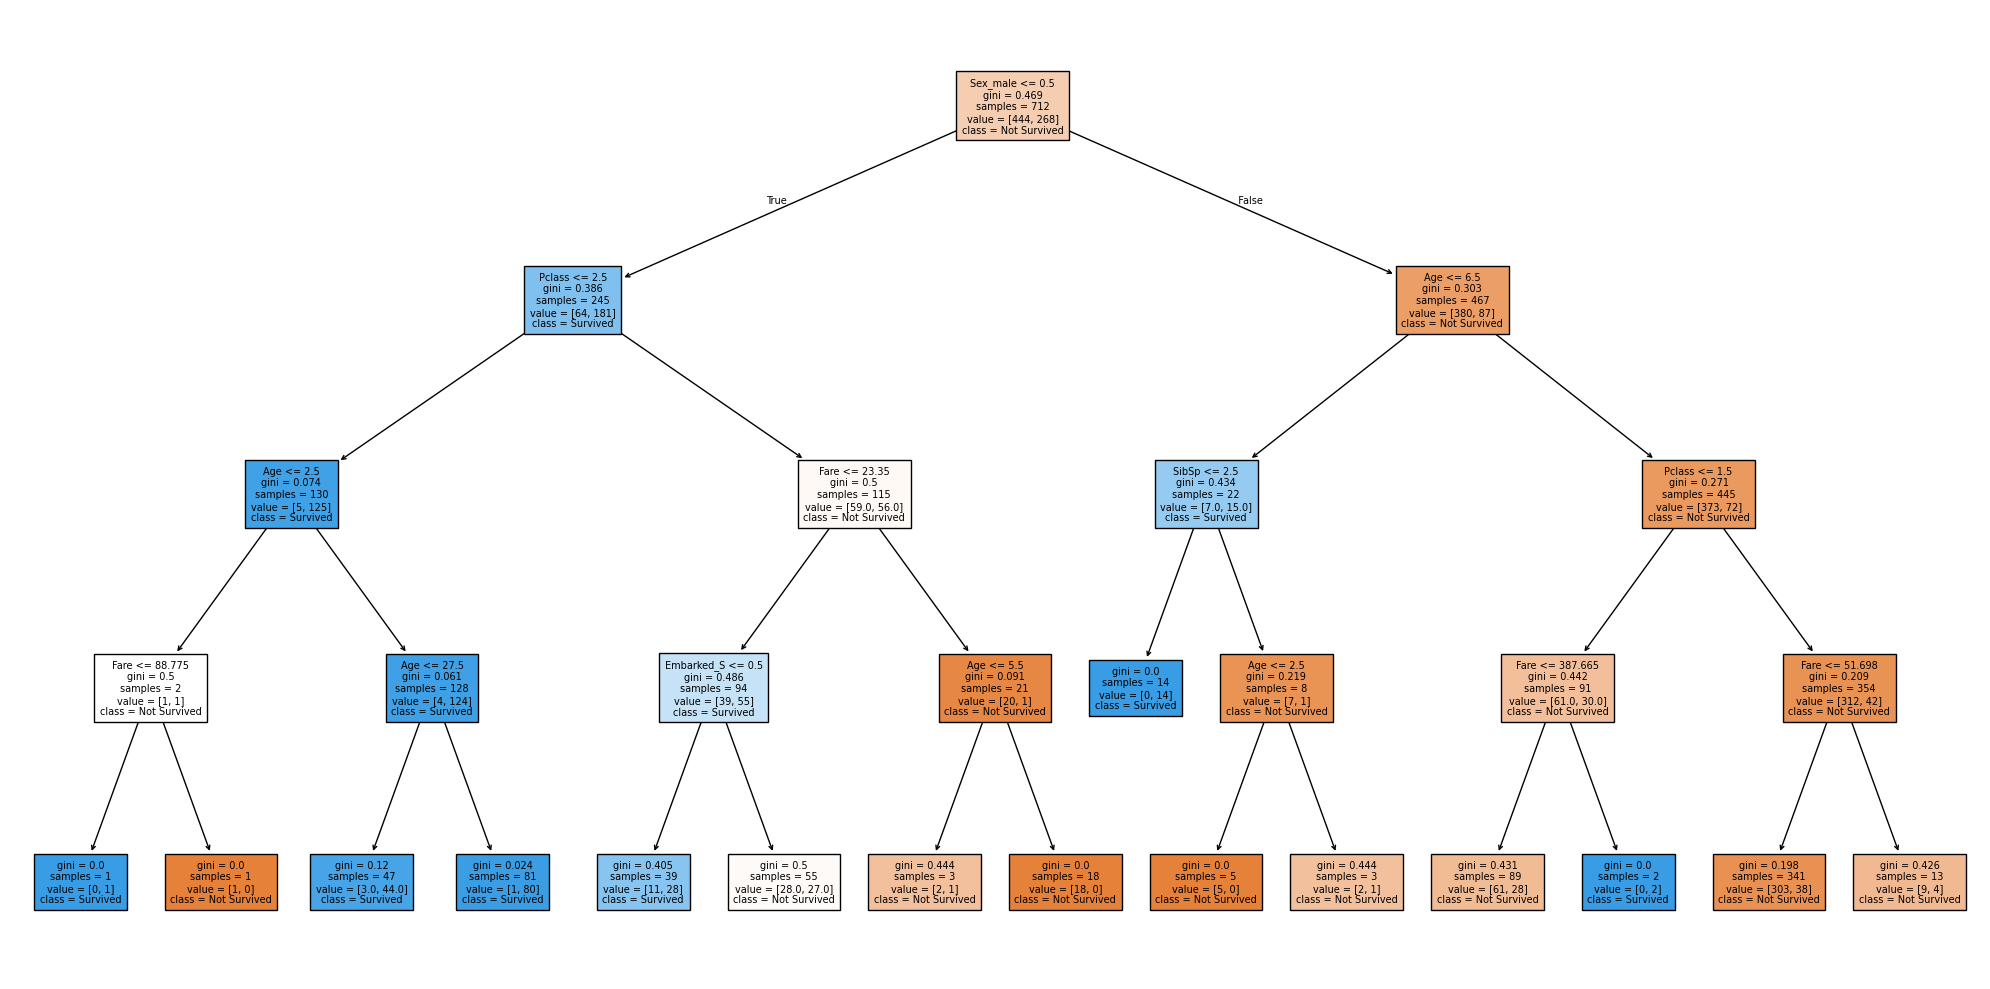

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("train.csv")

# Drop columns that aren’t useful for prediction
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Handle missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Define features and target
X = df_encoded.drop(columns=["Survived"])
y = df_encoded["Survived"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot and save tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["Not Survived", "Survived"], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig("titanic_decision_tree.png", dpi=150)
print("Saved tree image.")
